In [ ]:
!pip freeze
!python --version

In [1]:
!nvidia-smi

Sun Feb 22 22:23:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4000               On  |   00000000:86:00.0 Off |                  Off |
| 41%   27C    P8             16W /  140W |       1MiB /  16376MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [36]:
import datetime
import os

import numpy as np
from torch.utils.data import Subset, DataLoader

from leaf_seg.common.build import build_optimiser, build_scheduler
from leaf_seg.common.loss.cedice import CEDiceLoss
from leaf_seg.dataset.plantdreamer_semantic import build_dataloaders, build_dataset
from leaf_seg.semantic.build import build_reporter, setup_model
from leaf_seg.semantic.train import fit, run
from leaf_seg.semantic.finetune import finetune, load_pretrained_weights
from leaf_seg.common.config import SemanticTrainConfig, SemanticFinetuneConfig

In [2]:
import json
import re
from typing import Any
import pandas as pd
from pathlib import Path
import numpy as np

In [3]:


ROOT = Path("checkpoints/semantic/finetune/[20260220-190012]_segformer_finetunes")
FULL_TRAIN_REAL = 100 
MONITOR_COL = "metrics/mean_iou"   # primary metric
CONVERGENCE_RATIO = 0.95           # 95% of best metric

summary_rows = []
full_rows = []

# _subset_re = re.compile(r"\[subset-(?P<pct>\d+(?:\.\d+)?)\]")
# def extract_size_from_name(run_name: str, full_size: int = FULL_TRAIN_REAL) -> int:
#     """
#     Parse subset fraction from folder name and return number of real training images.
#     Example:
#       '...-finetune[subset-1.0]-...' -> 100
#       '...-finetune[subset-0.25]-...' -> 25
#     """
#     m = _subset_re.search(run_name)
#     if not m:
#         raise ValueError(f"Could not parse subset fraction from run name: {run_name}")
#     frac = float(m.group("pct"))
#     # convert fraction -> count; round to nearest int (or use floor if you prefer)
#     return int(round(frac * full_size))

_subset_re = re.compile(r"\[subset-(?P<n>\d+)\]")
def extract_real_count(run_name: str) -> int:
    m = _subset_re.search(run_name)
    if not m:
        raise ValueError(f"Could not parse subset size from: {run_name}")
    return int(m.group("n"))

def load_per_class_at_epoch(run_dir: Path, epoch: int) -> tuple[dict[int, float] | None, dict[int, float] | None]:
    p = run_dir / "per_class" / f"epoch_{epoch:03d}.json"
    if not p.exists():
        return None, None

    with p.open("r", encoding="utf-8") as f:
        data: dict[str, Any] = json.load(f)

    class_iou_raw = data.get("class_iou")
    class_dice_raw = data.get("class_dice")

    def to_int_keyed(d):
        if not isinstance(d, dict):
            return None
        out = {}
        for k, v in d.items():
            try:
                out[int(k)] = float(v)
            except Exception:
                pass
        return out or None

    return to_int_keyed(class_iou_raw), to_int_keyed(class_dice_raw)

for run_dir in ROOT.iterdir():
    if not run_dir.is_dir():
        continue

    print(str(run_dir))

    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        continue

    df = pd.read_csv(csv_path)

    real_count = extract_real_count(run_dir.name)

    best_idx = df["metrics/mean_iou"].idxmax()
    best_row = df.loc[best_idx]
    best_value = best_row[MONITOR_COL]
    best_epoch = int(best_row["epoch"])

    class_iou, class_dice = load_per_class_at_epoch(run_dir, best_epoch)

    

    # maximum generalisability gap = best_val/loss - best_train/loss
    df["gen_gap"] = df["val/loss"] - df["train/loss"]
    max_gap = df["gen_gap"].max()

    total_time = df["time/epoch"].sum()

    threshold = CONVERGENCE_RATIO * best_value
    conv_epoch = df[df[MONITOR_COL] >= threshold]["epoch"].iloc[0]

    summary_rows.append({
        "run": run_dir.name,
        "real_count": real_count,
        "best_epoch": best_epoch,
        "best_iou": best_value,
        "best_dice": best_row["metrics/mean_dice"],
        "class_iou": class_iou,
        "class_dice": class_dice,
        "best_overall_acc": best_row["metrics/overall_acc"],
        "val_loss_best": best_row["val/loss"],
        "convergence_epoch": conv_epoch,
        "max_generalisation_gap": max_gap,
        "total_training_time": total_time,
    })

    tmp = df.copy()
    tmp["run"] = run_dir.name
    tmp["real_count"] = real_count
    full_rows.append(tmp)

full = pd.concat(full_rows, ignore_index=True).sort_values(["real_count", "epoch"]).reset_index(drop=True)

summary = pd.DataFrame(summary_rows)
summary = summary.sort_values("real_count").reset_index(drop=True)
summary["delta_iou"] = summary["best_iou"].diff()
# Expand IoU
iou_wide = summary["class_iou"].apply(lambda d: d or {}).apply(pd.Series)
iou_wide = iou_wide.add_prefix("iou_c")

# Expand Dice
dice_wide = summary["class_dice"].apply(lambda d: d or {}).apply(pd.Series)
dice_wide = dice_wide.add_prefix("dice_c")

summary_wide = pd.concat([summary.drop(columns=["class_iou", "class_dice"]), iou_wide, dice_wide], axis=1)


checkpoints/semantic/finetune/[20260220-190012]_segformer_finetunes/20260220195549-finetune[subset-70]-segformer_mit_b2_bean_semantic_real
checkpoints/semantic/finetune/[20260220-190012]_segformer_finetunes/20260220202949-finetune[subset-100]-segformer_mit_b2_bean_semantic_real
checkpoints/semantic/finetune/[20260220-190012]_segformer_finetunes/20260220192613-finetune[subset-40]-segformer_mit_b2_bean_semantic_real
checkpoints/semantic/finetune/[20260220-190012]_segformer_finetunes/20260220190832-finetune[subset-20]-segformer_mit_b2_bean_semantic_real
checkpoints/semantic/finetune/[20260220-190012]_segformer_finetunes/20260220191719-finetune[subset-30]-segformer_mit_b2_bean_semantic_real
checkpoints/semantic/finetune/[20260220-190012]_segformer_finetunes/20260220194537-finetune[subset-60]-segformer_mit_b2_bean_semantic_real
checkpoints/semantic/finetune/[20260220-190012]_segformer_finetunes/finetune[subset-0]-segformer_mit_b2_bean_semantic_real
checkpoints/semantic/finetune/[20260220-19

In [4]:
np.shape(full_rows)

(11, 100, 15)

In [5]:
summary

,run,real_count,best_epoch,best_iou,best_dice,class_iou,class_dice,best_overall_acc,val_loss_best,convergence_epoch,max_generalisation_gap,total_training_time,delta_iou
0,finetune[subset-0]-segformer_mit_b2_bean_seman...,0,5,0.506067,0.621051,"{0: 0.9133818631254067, 1: 0.6453327613272675,...","{0: 0.954730344975097, 1: 0.7844404201940115, ...",0.908958,0.771638,3.0,0.858943,1240.631502,NaN
1,20260220190012-finetune[subset-10]-segformer_m...,10,100,0.748613,0.836300,"{0: 0.9910441490490608, 1: 0.8391896016914534,...","{0: 0.9955019325135424, 1: 0.9125645348578235,...",0.986547,0.165201,59.0,0.044757,269.875741,0.242546
2,20260220190832-finetune[subset-20]-segformer_m...,20,100,0.781829,0.858804,"{0: 0.9928977026453791, 1: 0.8667091055161427,...","{0: 0.9964361957238481, 1: 0.9285957870511364,...",0.989397,0.130900,42.0,0.032089,296.489943,0.033216
3,20260220191719-finetune[subset-30]-segformer_m...,30,81,0.802379,0.873842,"{0: 0.9939372875310849, 1: 0.881623859431515, ...","{0: 0.9969594267047275, 1: 0.9370883080722364,...",0.990833,0.109263,30.0,0.051427,325.427602,0.020550
4,20260220192613-finetune[subset-40]-segformer_m...,40,81,0.813821,0.881828,"{0: 0.994571235169546, 1: 0.8920237726521, 2: ...","{0: 0.9972782296592217, 1: 0.9429308294596389,...",0.991687,0.096877,24.0,0.034586,373.700987,0.011442
5,20260220193544-finetune[subset-50]-segformer_m...,50,74,0.816707,0.884019,"{0: 0.9946606707276315, 1: 0.8944374542179104,...","{0: 0.9973231891766228, 1: 0.9442776294635341,...",0.991865,0.094492,22.0,0.035372,396.879622,0.002886
6,20260220194537-finetune[subset-60]-segformer_m...,60,65,0.818975,0.885995,"{0: 0.994670129099037, 1: 0.8965325322528062, ...","{0: 0.9973279436919374, 1: 0.9454438740239854,...",0.991994,0.093413,21.0,0.030533,419.511054,0.002268
7,20260220195549-finetune[subset-70]-segformer_m...,70,77,0.824184,0.889856,"{0: 0.9948269622710253, 1: 0.9001171058524933,...","{0: 0.9974067737067853, 1: 0.9474332956427473,...",0.992286,0.090179,19.0,0.029195,445.252304,0.005209
8,20260220200629-finetune[subset-80]-segformer_m...,80,97,0.828034,0.892847,"{0: 0.9948702559841713, 1: 0.9032355221009181,...","{0: 0.9974285325070938, 1: 0.9491579067459466,...",0.992480,0.085745,19.0,0.026256,491.184613,0.003850
9,20260220201800-finetune[subset-90]-segformer_m...,90,67,0.833055,0.896736,"{0: 0.9949974111082105, 1: 0.9059941949771695,...","{0: 0.9974924333916751, 1: 0.9506788607905721,...",0.992684,0.081617,18.0,0.029495,513.948964,0.005021


In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

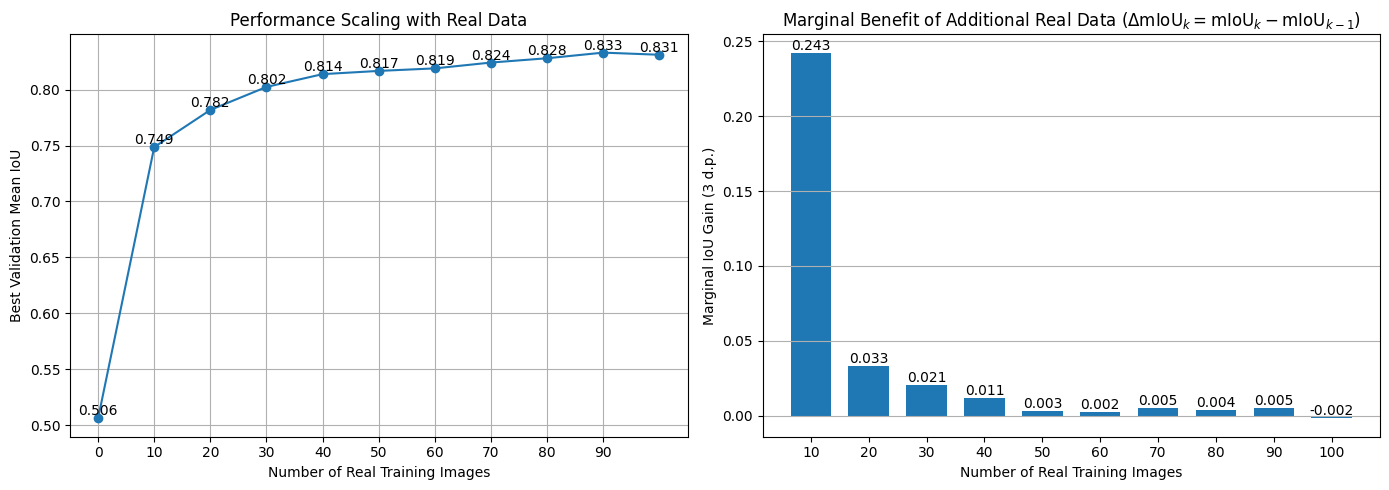

In [10]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Best Segm AP vs Real Data Size ---
x = summary["real_count"]
y = summary["best_iou"]

ax1.plot(x, y, marker="o")
for xi, yi in zip(x, y):
    ax1.text(xi, yi, f"{yi:.3f}", ha="center", va="bottom")


ax1.set_xlabel("Number of Real Training Images")
ax1.set_ylabel("Best Validation Mean IoU")
ax1.set_title("Performance Scaling with Real Data")
ax1.set_xticks(np.arange(0, 100, step=10))
ax1.grid(True)

# --- Right plot: Marginal Gain in Best Segm AP ---
bars = ax2.bar(summary["real_count"][1:], summary["delta_iou"][1:], width=7)

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

ax2.set_xlabel("Number of Real Training Images")
ax2.set_xticks(np.arange(10, 110, step=10))
ax2.set_ylabel("Marginal IoU Gain (3 d.p.)")
ax2.set_title(r"Marginal Benefit of Additional Real Data ($\Delta \text{mIoU}_k = \text{mIoU}_k - \text{mIoU}_{k-1}$)")

ax2.grid(True, axis="y", which="both")

plt.tight_layout()
plt.show()

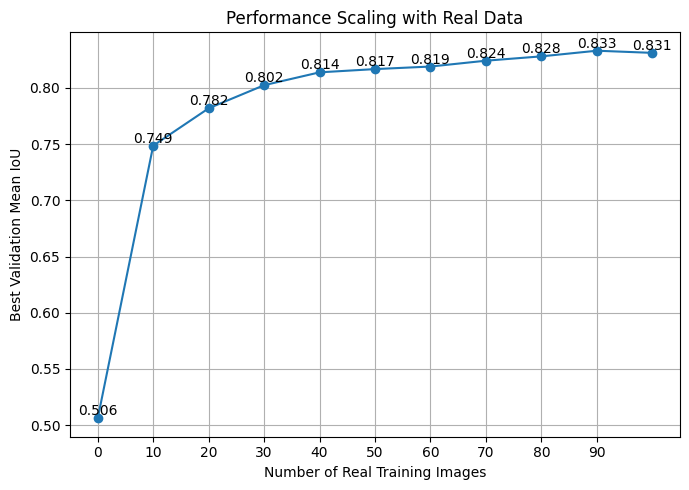

In [59]:
x = summary["real_count"]
y = summary["best_iou"]

plt.figure(figsize=(7,5))
plt.plot(x, y, marker="o")

# Add value labels
for xi, yi in zip(x, y):
    plt.text(xi, yi, f'{yi:.3f}',
             ha='center',
             va='bottom')

plt.xlabel("Number of Real Training Images")
plt.xticks(np.arange(0, 100, step=10))
plt.ylabel("Best Validation Mean IoU")
plt.title("Performance Scaling with Real Data")
plt.grid(True)
plt.tight_layout()
plt.show()

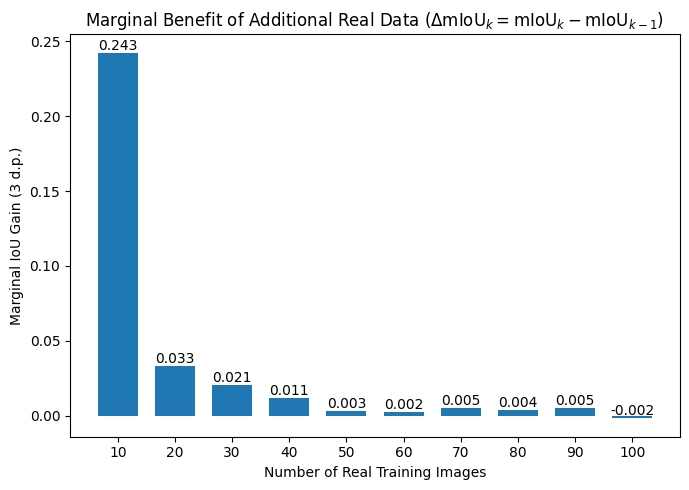

In [78]:
plt.figure(figsize=(7,5))
bars = plt.bar(summary["real_count"][1:], summary["delta_iou"][1:], width=7)
plt.xlabel("Number of Real Training Images")
plt.xticks(np.arange(10, 110, step=10))
plt.ylabel("Marginal IoU Gain (3 d.p.)")
plt.title(r"Marginal Benefit of Additional Real Data ($\Delta \text{mIoU}_k = \text{mIoU}_k - \text{mIoU}_{k-1}$)")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.3f}', ha='center',va='bottom')
plt.tight_layout()
plt.show()


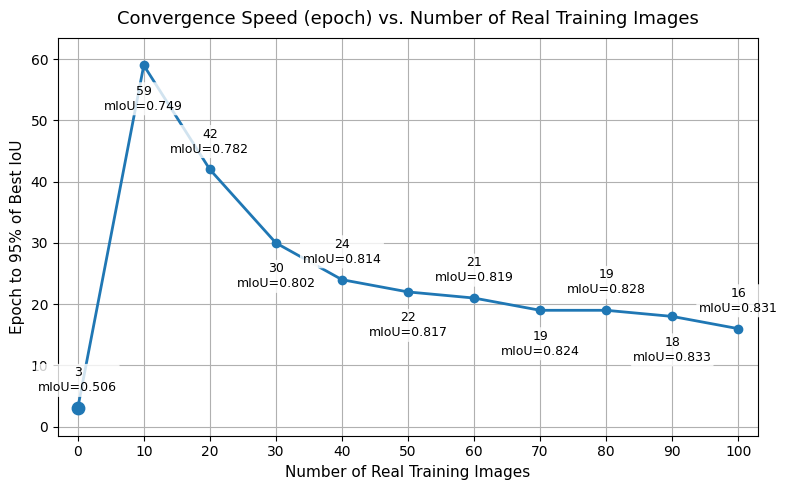

In [136]:
# x = summary["real_count"]
# y = summary["convergence_epoch"].astype(dtype=np.uint)

# plt.figure(figsize=(10,5))
# plt.plot(x, y, marker="o")

# for i, (xi, yi) in enumerate(zip(x, y)):
#     plt.text(xi, yi, f'{yi} (mIoU: {summary["best_iou"][i]:.3f})',
#              ha='center',
#              va='bottom')
    
# plt.xlabel("Number of Real Training Images")
# plt.xticks(np.arange(0, 110, step=10))
# plt.ylabel("Epoch to 95% of Best IoU")
# plt.title("Convergence Speed")
# plt.tight_layout()
# plt.show()
import numpy as np
import matplotlib.pyplot as plt

x = summary["real_count"].to_numpy()
y = summary["convergence_epoch"].astype(np.uint).to_numpy()
miou = summary["best_iou"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))

# Main line
ax.plot(x, y, marker="o", linewidth=2, markersize=6)

# Optional: highlight the baseline (x=0) point
if len(x) > 0:
    ax.scatter([x[0]], [y[0]], s=80, zorder=3)

# Annotate points with alternating offsets to reduce overlap
for i, (xi, yi, m) in enumerate(zip(x, y, miou)):
    # Alternate annotation positions (up/down) for readability
    dy = 10 if i % 2 == 0 else -14
    va = "bottom" if dy > 0 else "top"
    
    ax.annotate(
        f"{int(yi)}\nmIoU={m:.3f}",
        (xi, yi),
        xytext=(0, dy),
        textcoords="offset points",
        ha="center",
        va=va,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)
    )

# Axes formatting
ax.set_xlabel("Number of Real Training Images", fontsize=11)
ax.set_ylabel("Epoch to 95% of Best IoU", fontsize=11)
ax.set_title("Convergence Speed (epoch) vs. Number of Real Training Images", fontsize=13, pad=10)

ax.set_xticks(np.arange(0, max(x) + 10, 10))
ax.grid(True) #  linestyle="--", alpha=0.35

# Add a little padding around data limits
ax.margins(x=0.03, y=0.08)

plt.tight_layout()
plt.show()

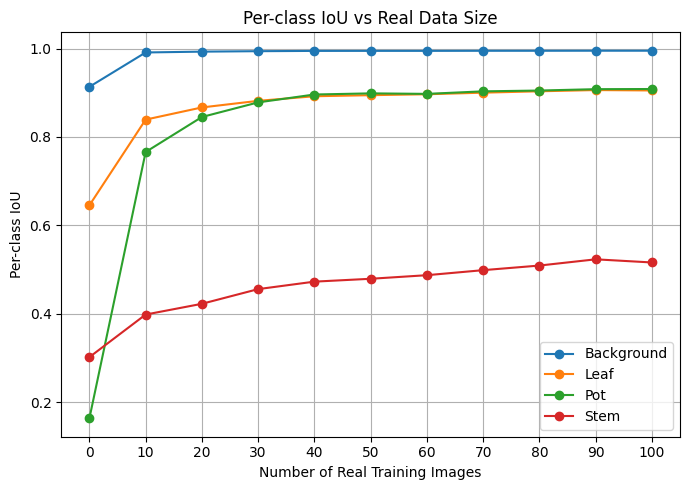

In [112]:
import matplotlib.pyplot as plt
import numpy as np

x = summary_wide["real_count"].values
iou_cols = [c for c in summary_wide.columns if c.startswith("iou_c")]
plt.figure(figsize=(7,5))
for c in iou_cols:
    plt.plot(x, summary_wide[c].values, marker="o", label=c)
plt.xlabel("Number of Real Training Images")
plt.ylabel("Per-class IoU")
plt.title("Per-class IoU vs Real Data Size")
plt.xticks(np.arange(0, 110, 10))
plt.grid(True)
plt.legend(labels=["Background", "Leaf", "Pot", "Stem"])
plt.tight_layout()
plt.show()

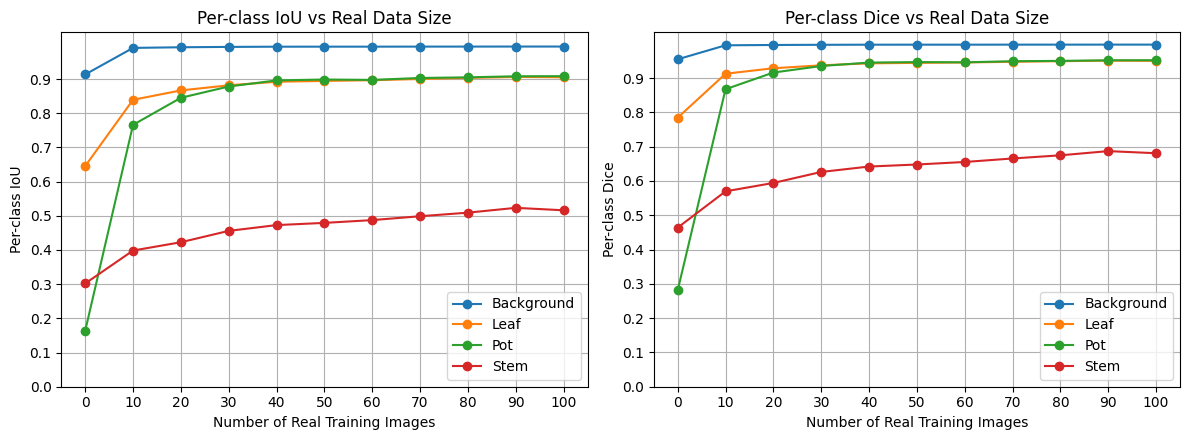

In [125]:

x = summary_wide["real_count"].values
iou_cols = [c for c in summary_wide.columns if c.startswith("iou_c")]
dice_cols = [c for c in summary_wide.columns if c.startswith("dice_c")]

# Create subplots (2 rows, 1 column) with shared x-axis
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

# --- Top subplot: IoU ---
for c in iou_cols:
    axes[0].plot(x, summary_wide[c].values, marker="o", label=c)
axes[0].set_ylabel("Per-class IoU")
axes[0].set_yticks(np.arange(0.0, 1.0, 0.1))
axes[0].set_xlabel("Number of Real Training Images")
axes[0].set_title("Per-class IoU vs Real Data Size")
axes[0].grid(True)
axes[0].legend(labels=["Background", "Leaf", "Pot", "Stem"])

# --- Bottom subplot: Dice ---
for c in dice_cols:
    axes[1].plot(x, summary_wide[c].values, marker="o", label=c)
axes[1].set_xlabel("Number of Real Training Images")
axes[1].set_ylabel("Per-class Dice")
axes[1].set_yticks(np.arange(0.0, 1.0, 0.1))
axes[1].set_title("Per-class Dice vs Real Data Size")
axes[1].set_xticks(np.arange(0, 110, 10))
axes[1].grid(True)
axes[1].legend(labels=["Background", "Leaf", "Pot", "Stem"], loc="lower right")

plt.tight_layout()
plt.show()

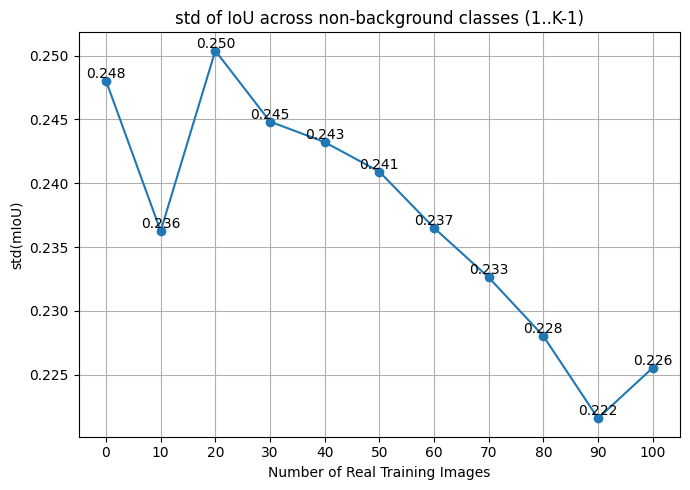

In [140]:
# example: std of IoU across non-background classes (1..K-1)
non_bg = [c for c in iou_cols if c != "iou_c0"]
summary_wide["iou_std_nonbg"] = summary_wide[non_bg].std(axis=1)

x = summary_wide["real_count"]
y = summary_wide["iou_std_nonbg"]

plt.figure(figsize=(7,5))
plt.plot(x, y, marker="o")

for xi, yi in zip(x, y):
    plt.text(xi, yi, f'{yi:.3f}',
             ha='center',
             va='bottom')

plt.xlabel("Number of Real Training Images")
plt.xticks(np.arange(0,110,step=10))
plt.ylabel("std(mIoU)")
plt.title("std of IoU across non-background classes (1..K-1)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [104]:
full.columns

Index(['epoch', 'train/loss', 'val/loss', 'metrics/mean_iou',
       'metrics/mean_dice', 'metrics/overall_acc', 'metrics/mean_acc',
       'metrics/freqw_acc', 'lr', 'time/train', 'time/val', 'time/epoch',
       'gen_gap', 'run', 'real_count'],
      dtype='str')

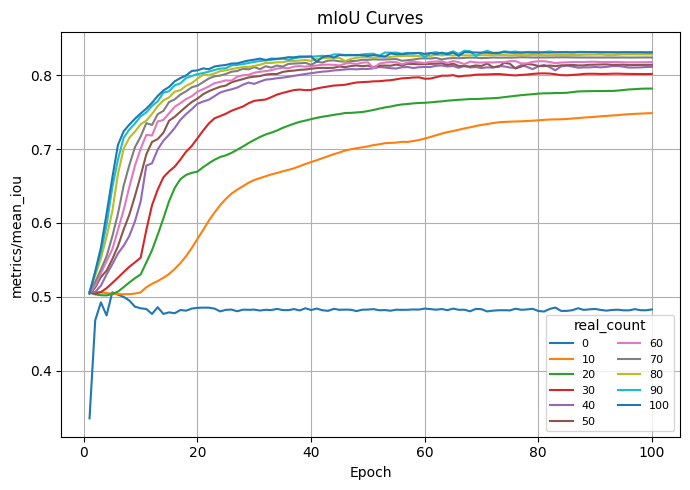

In [111]:
plt.figure(figsize=(7,5))
for rc, g in full.groupby("real_count"):
    plt.plot(g["epoch"], g["metrics/mean_iou"], label=str(rc))
plt.xlabel("Epoch")
plt.ylabel("metrics/mean_iou")
plt.title("mIoU Curves")
plt.grid(True)
plt.legend(title="real_count", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

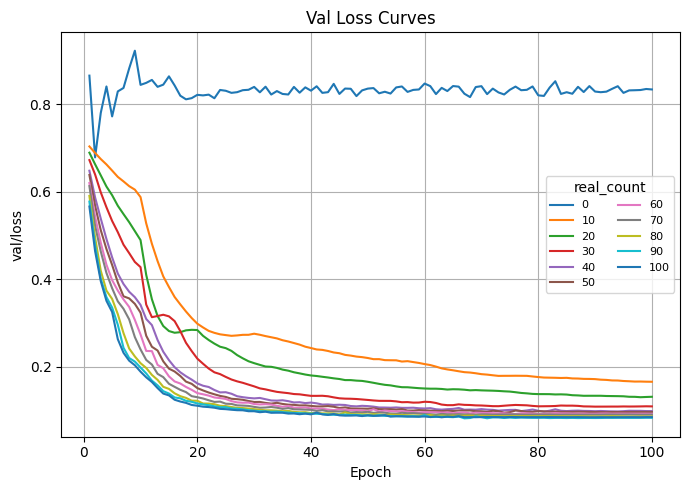

In [ ]:
plt.figure(figsize=(7,5))
for rc, g in full.groupby("real_count"):
    plt.plot(g["epoch"], g["val/loss"], label=str(rc))
plt.xlabel("Epoch")
plt.ylabel("val/loss")
plt.title("Val Loss Curves")
plt.grid(True)
plt.legend(title="real_count", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

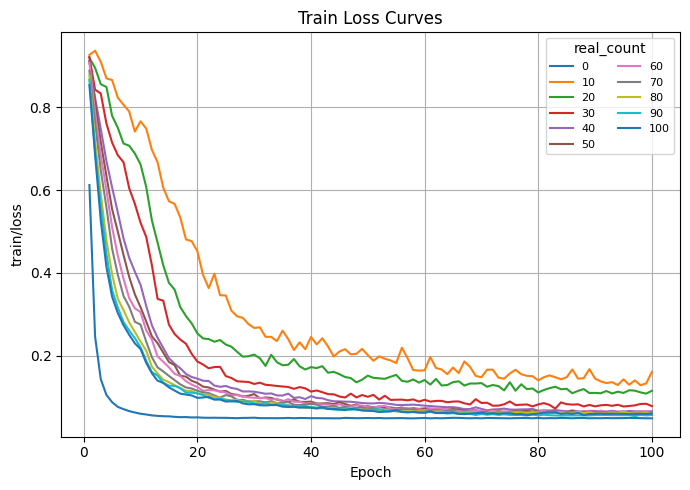

In [108]:
plt.figure(figsize=(7,5))
for rc, g in full.groupby("real_count"):
    plt.plot(g["epoch"], g["train/loss"], label=str(rc))
plt.xlabel("Epoch")
plt.ylabel("train/loss")
plt.title("Train Loss Curves")
plt.grid(True)
plt.legend(title="real_count", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

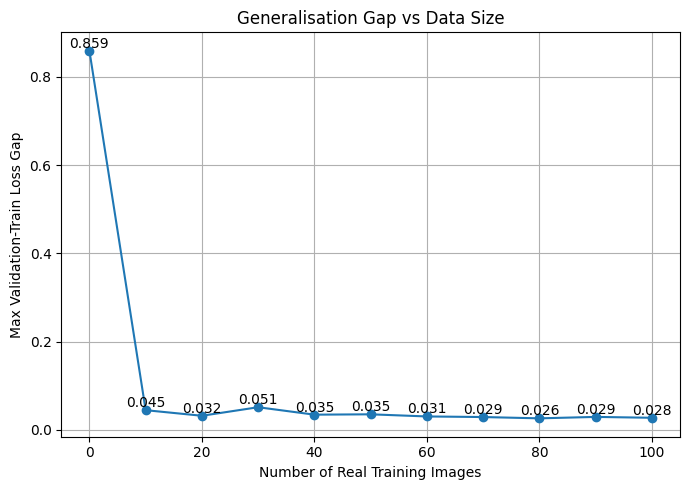

In [142]:
x = summary["real_count"]
y = summary["max_generalisation_gap"]

plt.figure(figsize=(7,5))
plt.plot(x, y, marker="o")

for xi, yi in zip(x, y):
    plt.text(xi, yi, f'{yi:.3f}',
             ha='center',
             va='bottom')

plt.xlabel("Number of Real Training Images")
plt.ylabel("Max Validation-Train Loss Gap")
plt.title("Generalisation Gap vs Data Size")
plt.tight_layout()
plt.grid(True)
plt.show()

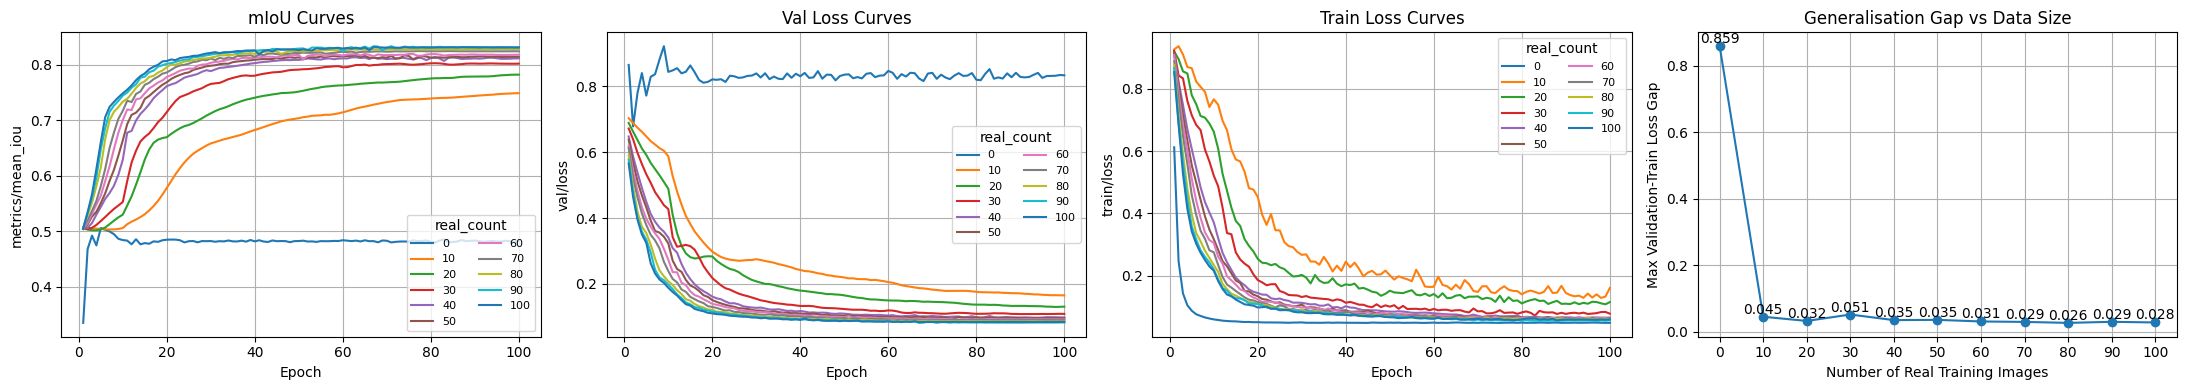

In [18]:

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
(ax1, ax2, ax3, ax4) = axes

# 1) mIoU curves
for rc, g in full.groupby("real_count"):
    ax1.plot(g["epoch"], g["metrics/mean_iou"], label=str(rc))
ax1.set_xlabel("Epoch")
ax1.set_ylabel("metrics/mean_iou")
ax1.set_title("mIoU Curves")
ax1.grid(True)
ax1.legend(title="real_count", ncol=2, fontsize=8)

# 2) Val loss curves
for rc, g in full.groupby("real_count"):
    ax2.plot(g["epoch"], g["val/loss"], label=str(rc))
ax2.set_xlabel("Epoch")
ax2.set_ylabel("val/loss")
ax2.set_title("Val Loss Curves")
ax2.grid(True)
ax2.legend(title="real_count", ncol=2, fontsize=8)

# 3) Train loss curves
for rc, g in full.groupby("real_count"):
    ax3.plot(g["epoch"], g["train/loss"], label=str(rc))
ax3.set_xlabel("Epoch")
ax3.set_ylabel("train/loss")
ax3.set_title("Train Loss Curves")
ax3.grid(True)
ax3.legend(title="real_count", ncol=2, fontsize=8)

# 4) Generalisation gap vs data size
x = summary["real_count"]
y = summary["max_generalisation_gap"]

ax4.plot(x, y, marker="o")
for xi, yi in zip(x, y):
    ax4.text(xi, yi, f"{yi:.3f}", ha="center", va="bottom")
ax4.set_xlabel("Number of Real Training Images")
ax4.set_xticks(np.arange(0,110,10))
ax4.set_ylabel("Max Validation-Train Loss Gap")
# ax4.set_yticks(np.arange(0.0, 1.1, 0.1))
ax4.set_title("Generalisation Gap vs Data Size")
ax4.grid(True)

plt.tight_layout()
plt.show()